# Customer Segmentation Analysis

## Objective
The objective of this project is to segment customers based on Income, Age, and Total Spending using K-Means Clustering. The results help businesses understand customer groups and create targeted marketing strategies.

## K-Means Clustering

K-Means clustering is an unsupervised machine learning algorithm used to group similar customers into distinct segments based on their characteristics.

## Data Loading

In [1]:
import pandas as pd

df = pd.read_csv('ifood_df.csv')

In [2]:
df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                2205 non-null   float64
 1   Kidhome               2205 non-null   int64  
 2   Teenhome              2205 non-null   int64  
 3   Recency               2205 non-null   int64  
 4   MntWines              2205 non-null   int64  
 5   MntFruits             2205 non-null   int64  
 6   MntMeatProducts       2205 non-null   int64  
 7   MntFishProducts       2205 non-null   int64  
 8   MntSweetProducts      2205 non-null   int64  
 9   MntGoldProds          2205 non-null   int64  
 10  NumDealsPurchases     2205 non-null   int64  
 11  NumWebPurchases       2205 non-null   int64  
 12  NumCatalogPurchases   2205 non-null   int64  
 13  NumStorePurchases     2205 non-null   int64  
 14  NumWebVisitsMonth     2205 non-null   int64  
 15  AcceptedCmp3         

In [4]:
df.shape

(2205, 39)

In [5]:
df.describe()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,...,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.00000
mean,51622.094785,0.442177,0.506576,49.009070,306.164626,26.403175,165.312018,37.756463,27.128345,44.057143,...,0.257596,0.034467,0.089796,0.024490,0.504762,0.165079,0.215873,562.764626,518.707483,0.29932
std,20713.063826,0.537132,0.544380,28.932111,337.493839,39.784484,217.784507,54.824635,41.130468,51.736211,...,0.437410,0.182467,0.285954,0.154599,0.500091,0.371336,0.411520,575.936911,553.847248,0.68044
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,-283.000000,0.00000
25%,35196.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000,42.000000,0.00000
50%,51287.000000,0.000000,0.000000,49.000000,178.000000,8.000000,68.000000,12.000000,8.000000,25.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,343.000000,288.000000,0.00000
75%,68281.000000,1.000000,1.000000,74.000000,507.000000,33.000000,232.000000,50.000000,34.000000,56.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,964.000000,884.000000,0.00000
max,113734.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2491.000000,2458.000000,4.00000


In [6]:
df.isnull().sum()

,0
Income,0
Kidhome,0
Teenhome,0
Recency,0
MntWines,0
MntFruits,0
MntMeatProducts,0
MntFishProducts,0
MntSweetProducts,0
MntGoldProds,0


In [7]:
df.duplicated().sum()

np.int64(184)

In [10]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Customer_Days', 'marital_Divorced', 'marital_Married',
       'marital_Single', 'marital_Together', 'marital_Widow',
       'education_2n Cycle', 'education_Basic', 'education_Graduation',
       'education_Master', 'education_PhD', 'MntTotal', 'MntRegularProds',
       'AcceptedCmpOverall'],
      dtype='object')

In [12]:
features = df[['Income', 'Age', 'MntTotal']]
features.head()

,Income,Age,MntTotal
0,58138.0,63,1529
1,46344.0,66,21
2,71613.0,55,734
3,26646.0,36,48
4,58293.0,39,407


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [14]:
print(scaled_features[:5])

[[ 0.3115108   1.01868898  1.67387355]
 [-0.2580297   1.27587455 -0.94130787]
 [ 0.96222798  0.33286081  0.29518043]
 [-1.2092599  -1.29598109 -0.89448433]
 [ 0.31899586 -1.03879552 -0.27190467]]


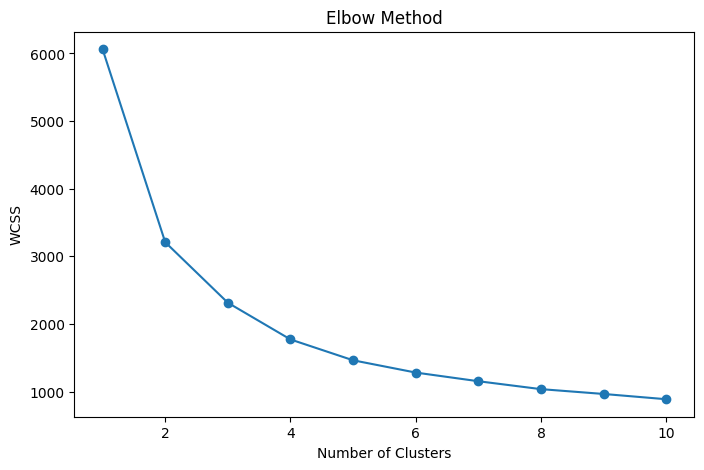

In [15]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

In [16]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)

df['Cluster'] = kmeans.fit_predict(scaled_features)

In [17]:
df['Cluster'].value_counts()

,count
Cluster,
3,721
0,512
1,406
2,382


In [18]:
df.groupby('Cluster')[['Income','Age','MntTotal']].mean()

,Income,Age,MntTotal
Cluster,,,
0,45865.390625,60.826172,240.000000
1,72736.049261,42.795567,1194.312808
2,72027.102094,63.431937,1168.479058
3,33192.345354,42.384189,118.291262


In [19]:
df['Cluster'].value_counts()

,count
Cluster,
3,721
0,512
1,406
2,382


In [20]:
df.groupby('Cluster')[['Income','Age','MntTotal']].mean()

,Income,Age,MntTotal
Cluster,,,
0,45865.390625,60.826172,240.000000
1,72736.049261,42.795567,1194.312808
2,72027.102094,63.431937,1168.479058
3,33192.345354,42.384189,118.291262


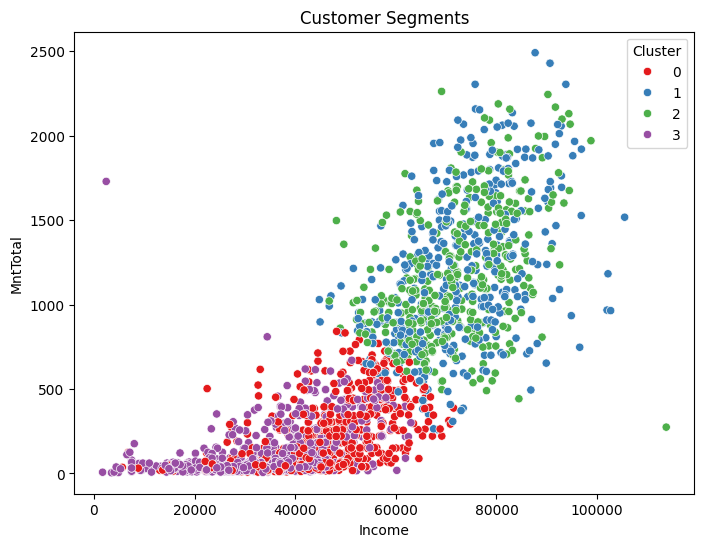

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Income',
    y='MntTotal',
    hue='Cluster',
    palette='Set1'
)

plt.title('Customer Segments')
plt.show()

## Insights

1. Cluster 1 contains high-income customers with the highest spending behavior.

2. Cluster 2 contains wealthy senior customers who also spend significantly.

3. Cluster 3 contains budget customers with the lowest income and spending.

4. Cluster 0 contains older customers with moderate income but lower spending.

5. Customer spending is strongly influenced by income level.

## Recommendations

1. Offer premium products and loyalty programs to Cluster 1 customers.

2. Provide personalized offers for Cluster 2 customers.

3. Create discount campaigns for Cluster 3 customers.

4. Encourage Cluster 0 customers to increase spending through targeted promotions.

5. Develop separate marketing strategies for each customer segment.

## Conclusion

This project applied K-Means clustering to segment customers based on Income, Age, and Total Spending. Four distinct customer groups were identified. These segments can help businesses design targeted marketing campaigns and improve customer engagement.